In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Small_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Large_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Large_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Patterns.txt
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Medium_Patterns.txt
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_accounts.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_Trans.csv
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Large_Patterns.txt
/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/LI-Medium_Patterns.txt
/kaggle/in

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import psutil

def check_memory():
    memory = psutil.virtual_memory()
    print(f"Memory used: {memory.percent}%")
    print(f"Available: {memory.available / 1024**2:.0f}MB")

In [4]:
def fix_data_types(df):
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    
    return df

In [5]:
def load_data_safe(file_path, max_rows=500000):
    dtype_dict = {
        'step': 'int32',
        'amount': 'float32',
        'isFraud': 'int8'
    }
    
    df = pd.read_csv(file_path, dtype=dtype_dict, nrows=max_rows)
    return df

In [6]:
def memory_warning():
    memory_percent = psutil.virtual_memory().percent
    if memory_percent > 80:
        print("WARNING: Memory getting full!")
        return True
    return False

In [7]:
import gc

def cleanup_memory():
    gc.collect()
    print("Memory cleaned up")

In [8]:
check_memory()
trans_df = load_data_safe("/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_Trans.csv")
trans_df = fix_data_types(trans_df)
cleanup_memory()
check_memory()

Memory used: 4.2%
Available: 30769MB
Memory cleaned up
Memory used: 4.4%
Available: 30680MB


In [9]:
accounts_df = pd.read_csv("/kaggle/input/ibm-transactions-for-anti-money-laundering-aml/HI-Small_accounts.csv") 
accounts_df = fix_data_types(accounts_df)
cleanup_memory()
check_memory()


Memory cleaned up
Memory used: 4.9%
Available: 30534MB


In [10]:
print(f"Transactions loaded: {len(trans_df)} rows")

Transactions loaded: 500000 rows


In [11]:
print(f"Accounts loaded: {len(accounts_df)} rows")

Accounts loaded: 518581 rows


In [12]:
check_memory()
cleanup_memory()

Memory used: 4.9%
Available: 30541MB
Memory cleaned up


In [13]:
print("Transaction columns:")
print(trans_df.columns.tolist()) # gives all the columns in the table
print("\nFirst few transactions:")
print(trans_df.head())

Transaction columns:
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

First few transactions:
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Doll

In [14]:
print("Account columns:")
print(accounts_df.columns.tolist())
print("\nFirst few accounts:")
print(accounts_df.head())


Account columns:
['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']

First few accounts:
                     Bank Name  Bank ID Account Number  Entity ID  \
0          Portugal Bank #4507   331579      80B779D80  80062E240   
1              Canada Bank #27      210      809D86900  800C998A0   
2                  UK Bank #33    21884      80812BE00  800C47F50   
3           Germany Bank #4815    32742      81047F300  80096F0B0   
4  National Bank of Harrisburg   127390      80BD8CF00  800FB8760   

                  Entity Name  
0  Sole Proprietorship #50438  
1          Corporation #33520  
2          Partnership #35397  
3          Corporation #48813  
4            Corporation #889  


In [15]:
print(f"\nFraud in transactions: {trans_df['Is Laundering'].sum()} out of {len(trans_df)}")
print(f"Fraud rate: {trans_df['Is Laundering'].mean():.4f}")


Fraud in transactions: 193 out of 500000
Fraud rate: 0.0004


In [16]:
print("Are datasets identical?", trans_df.equals(accounts_df))

Are datasets identical? False


In [17]:
print("Missing values in transactions:")
print(trans_df.isnull().sum())

print("\nMissing values in accounts:")
print(accounts_df.isnull().sum())

print("\nTransaction data types:")
print(trans_df.dtypes)

print("\nAccount data types:")
print(accounts_df.dtypes)

Missing values in transactions:
Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

Missing values in accounts:
Bank Name         0
Bank ID           0
Account Number    0
Entity ID         0
Entity Name       0
dtype: int64

Transaction data types:
Timestamp              object
From Bank               int32
Account                object
To Bank                 int32
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering            int8
dtype: object

Account data types:
Bank Name         object
Bank ID            int32
Account Number    object
Entity ID         object
Entity Name       object
dtype: object


In [19]:
print("Transaction amounts summary:")
print(trans_df[['Amount Received', 'Amount Paid']].describe())

print("\nPayment formats:")
print(trans_df['Payment Format'].value_counts())

print("\nCurrencies:")
print(trans_df['Receiving Currency'].value_counts())

print("\nBanks involved:")
print(f"Unique banks: {trans_df['From Bank'].nunique()}")
print(f"Bank range: {trans_df['From Bank'].min()} to {trans_df['From Bank'].max()}")

Transaction amounts summary:
       Amount Received   Amount Paid
count     5.000000e+05  5.000000e+05
mean      6.981517e+06  6.073695e+06
std       4.436369e+08  3.697630e+08
min       1.000000e-06  1.000000e-06
25%       4.787000e+01  4.811750e+01
50%       2.132940e+03  2.139340e+03
75%       3.213862e+04  3.210696e+04
max       1.402124e+11  1.402124e+11

Payment formats:
Payment Format
Reinvestment    285394
Cheque           81362
Credit Card      59045
ACH              30531
Cash             21250
Bitcoin          13914
Wire              8504
Name: count, dtype: int64

Currencies:
Receiving Currency
US Dollar            189420
Euro                 114387
Swiss Franc           23211
Yuan                  20347
Shekel                19072
Rupee                 18808
UK Pound              17001
Yen                   15557
Ruble                 15204
Bitcoin               14013
Australian Dollar     13333
Canadian Dollar       13328
Mexican Peso          11043
Saudi Riyal           

In [20]:
print("Account data summary:")
print(f"Total accounts: {len(accounts_df)}")
print(f"Unique banks: {accounts_df['Bank Name'].nunique()}")
print(f"Unique entities: {accounts_df['Entity Name'].nunique()}")

print("\nTop banks:")
print(accounts_df['Bank Name'].value_counts().head())

print("\nEntity types:")
print(accounts_df['Entity Name'].value_counts().head())

# Check account overlap
trans_accounts = set(trans_df['Account'].tolist() + trans_df['Account.1'].tolist())
master_accounts = set(accounts_df['Account Number'].tolist())
overlap = len(trans_accounts.intersection(master_accounts))
print(f"\nAccount overlap: {overlap} accounts found in both datasets")

Account data summary:
Total accounts: 518581
Unique banks: 20053
Unique entities: 166207

Top banks:
Bank Name
National Bank of Laramie       3797
National Bank of the East      3663
Japan Bank #0                  3051
Arbor Savings Bank             2894
National Bank of Pittsburgh    2683
Name: count, dtype: int64

Entity types:
Entity Name
Corporation #34854            7820
Country #1                    6677
Corporation #35871            4645
Sole Proprietorship #32941    3743
Corporation #33736            3402
Name: count, dtype: int64

Account overlap: 326815 accounts found in both datasets


In [21]:
trans_df['Timestamp'] = pd.to_datetime(trans_df['Timestamp'])
trans_df['hour'] = trans_df['Timestamp'].dt.hour
trans_df['day_of_week'] = trans_df['Timestamp'].dt.dayofweek

# Financial features
trans_df['amount_ratio'] = trans_df['Amount Received'] / trans_df['Amount Paid']
trans_df['amount_ratio'] = trans_df['amount_ratio'].replace([np.inf, -np.inf], 1)
trans_df['amount_log'] = np.log1p(trans_df['Amount Received'])

# Currency mismatch flag
trans_df['currency_mismatch'] = (trans_df['Receiving Currency'] != trans_df['Payment Currency']).astype(int)

print("Added features:")
print("- hour, day_of_week")
print("- amount_ratio, amount_log")  
print("- currency_mismatch")
print(f"New shape: {trans_df.shape}")

Added features:
- hour, day_of_week
- amount_ratio, amount_log
- currency_mismatch
New shape: (500000, 16)


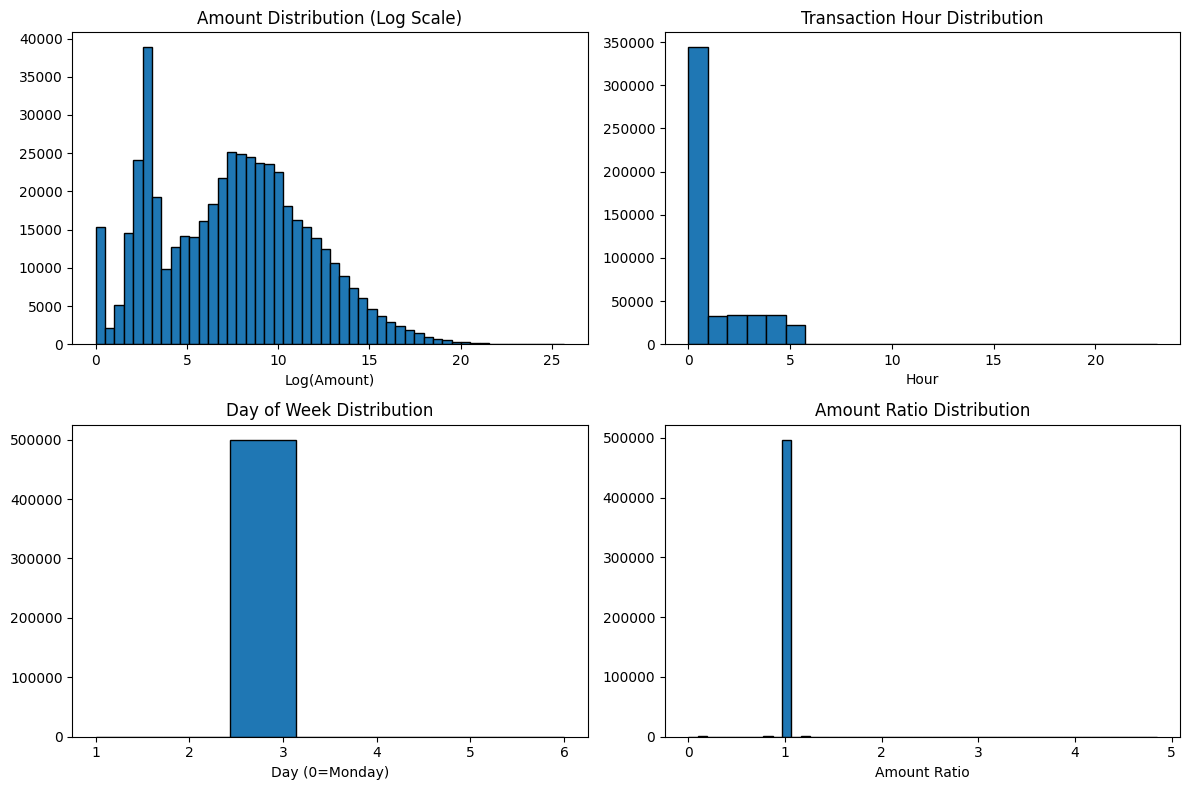

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Amount distribution (log scale)
axes[0,0].hist(trans_df['amount_log'], bins=50, edgecolor='black')
axes[0,0].set_title('Amount Distribution (Log Scale)')
axes[0,0].set_xlabel('Log(Amount)')

# Hour distribution  
axes[0,1].hist(trans_df['hour'], bins=24, edgecolor='black')
axes[0,1].set_title('Transaction Hour Distribution')
axes[0,1].set_xlabel('Hour')

# Day of week distribution
axes[1,0].hist(trans_df['day_of_week'], bins=7, edgecolor='black') 
axes[1,0].set_title('Day of Week Distribution')
axes[1,0].set_xlabel('Day (0=Monday)')

# Amount ratio distribution (limited range)
axes[1,1].hist(trans_df[trans_df['amount_ratio'] <= 5]['amount_ratio'], bins=50, edgecolor='black')
axes[1,1].set_title('Amount Ratio Distribution')
axes[1,1].set_xlabel('Amount Ratio')

plt.tight_layout()
plt.show()

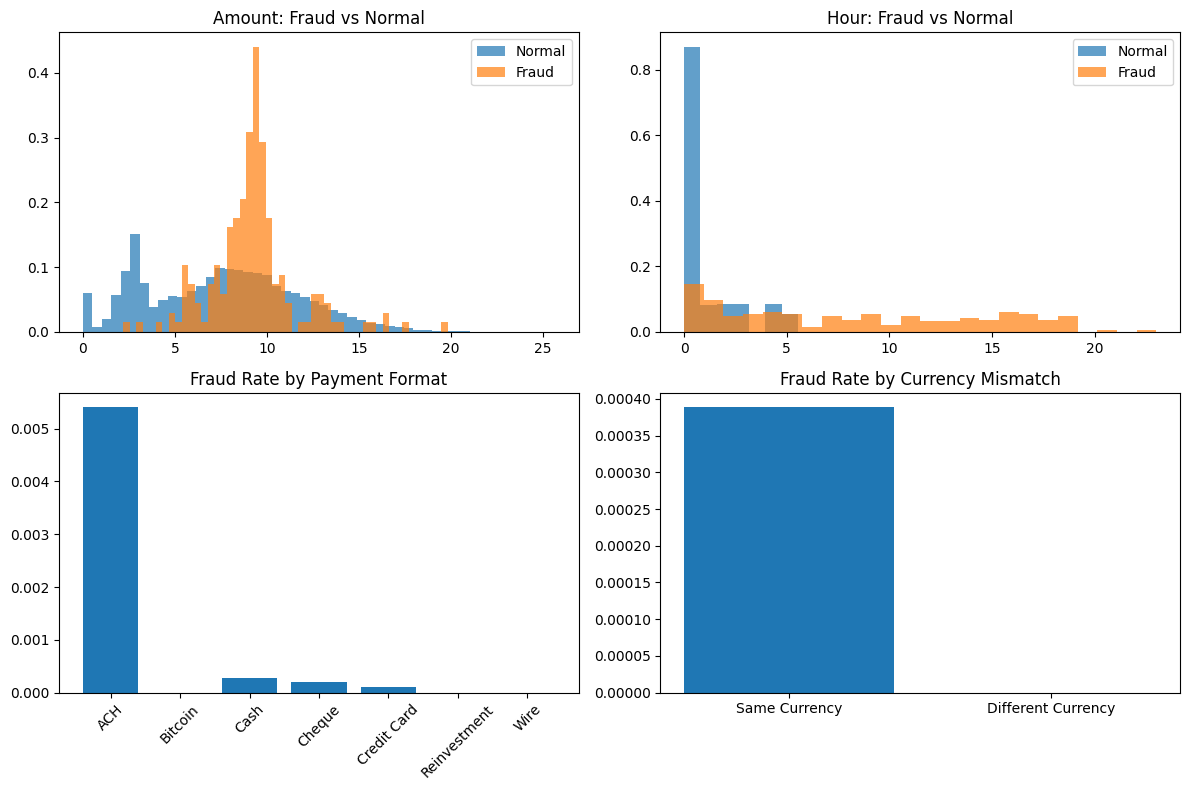

In [23]:
fraud_df = trans_df[trans_df['Is Laundering'] == 1]
normal_df = trans_df[trans_df['Is Laundering'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Amount comparison
axes[0,0].hist(normal_df['amount_log'], bins=50, alpha=0.7, label='Normal', density=True)
axes[0,0].hist(fraud_df['amount_log'], bins=50, alpha=0.7, label='Fraud', density=True)
axes[0,0].set_title('Amount: Fraud vs Normal')
axes[0,0].legend()

# Hour comparison
axes[0,1].hist(normal_df['hour'], bins=24, alpha=0.7, label='Normal', density=True)
axes[0,1].hist(fraud_df['hour'], bins=24, alpha=0.7, label='Fraud', density=True) 
axes[0,1].set_title('Hour: Fraud vs Normal')
axes[0,1].legend()

# Payment format fraud rates
fraud_by_format = trans_df.groupby('Payment Format')['Is Laundering'].mean()
axes[1,0].bar(fraud_by_format.index, fraud_by_format.values)
axes[1,0].set_title('Fraud Rate by Payment Format')
axes[1,0].tick_params(axis='x', rotation=45)

# Currency mismatch comparison
mismatch_fraud = trans_df.groupby('currency_mismatch')['Is Laundering'].mean()
axes[1,1].bar(['Same Currency', 'Different Currency'], mismatch_fraud.values)
axes[1,1].set_title('Fraud Rate by Currency Mismatch')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


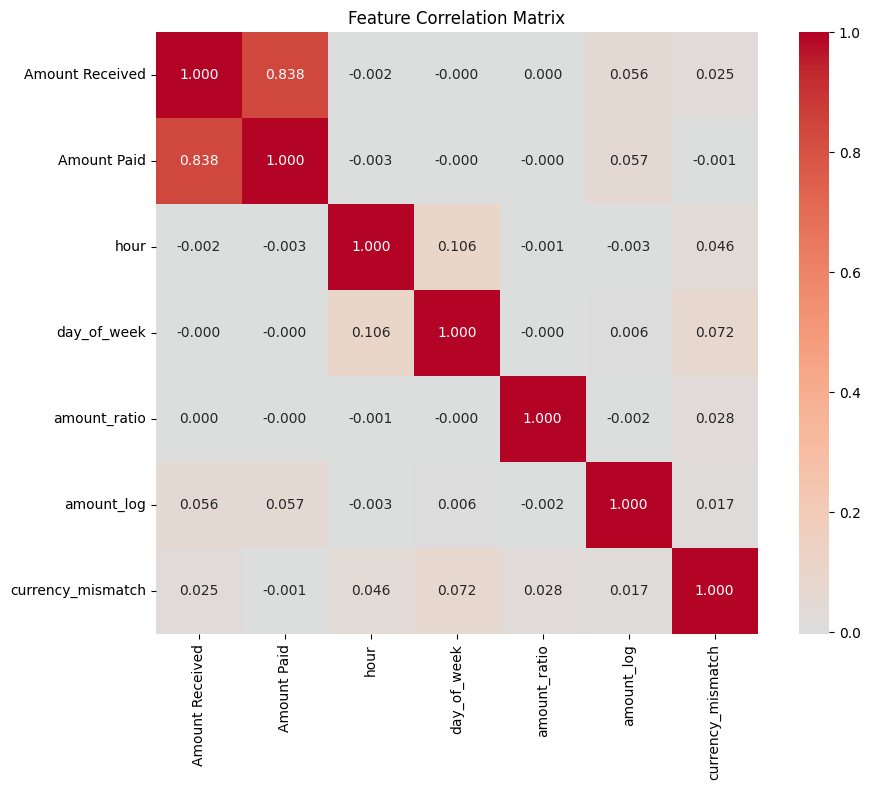

High correlations (>0.7):
Amount Received - Amount Paid: 0.838


In [24]:
# Correlation matrix for numerical features
numerical_cols = ['Amount Received', 'Amount Paid', 'hour', 'day_of_week', 
                  'amount_ratio', 'amount_log', 'currency_mismatch']

correlation_matrix = trans_df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Print high correlations
print("High correlations (>0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val > 0.7:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"{col1} - {col2}: {corr_val:.3f}")

In [25]:
trans_df['is_round_amount'] = ((trans_df['Amount Received'] % 1000) == 0).astype(int)

# High-value transaction flag (top 5%)
high_value_threshold = trans_df['Amount Received'].quantile(0.95)
trans_df['is_high_value'] = (trans_df['Amount Received'] > high_value_threshold).astype(int)

# Unusual timing (late night/early morning)
trans_df['is_unusual_hour'] = trans_df['hour'].apply(
    lambda x: 1 if x <= 5 or x >= 22 else 0
)

# Structuring detection (amounts just under reporting thresholds)
trans_df['near_threshold'] = trans_df['Amount Received'].apply(
    lambda x: 1 if 9000 <= x <= 9999 else 0  # Just under $10K threshold
)

# Same bank transaction (could be layering)
trans_df['same_bank'] = (trans_df['From Bank'] == trans_df['To Bank']).astype(int)

print(f"Updated shape: {trans_df.shape}")

Updated shape: (500000, 21)


In [26]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns to encode
categorical_cols = ['Payment Format', 'Receiving Currency', 'Payment Currency']

print("Encoding categorical variables...")
print("Original categorical distributions:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(trans_df[col].value_counts().head(3))

# Create label encoders
label_encoders = {}
trans_encoded = trans_df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    trans_encoded[col] = le.fit_transform(trans_df[col])
    label_encoders[col] = le
    
    print(f"\n{col} encoding sample:")
    unique_vals = trans_df[col].unique()[:3]
    for val in unique_vals:
        encoded_val = le.transform([val])[0]
        print(f"  '{val}' -> {encoded_val}")

print(f"\nFinal encoded shape: {trans_encoded.shape}")
print(f"Categorical columns now numerical: {categorical_cols}")

Encoding categorical variables...
Original categorical distributions:

Payment Format:
Payment Format
Reinvestment    285394
Cheque           81362
Credit Card      59045
Name: count, dtype: int64

Receiving Currency:
Receiving Currency
US Dollar      189420
Euro           114387
Swiss Franc     23211
Name: count, dtype: int64

Payment Currency:
Payment Currency
US Dollar      190123
Euro           114124
Swiss Franc     23054
Name: count, dtype: int64

Payment Format encoding sample:
  'Reinvestment' -> 5
  'Cheque' -> 3
  'Credit Card' -> 4

Receiving Currency encoding sample:
  'US Dollar' -> 12
  'Bitcoin' -> 1
  'Euro' -> 4

Payment Currency encoding sample:
  'US Dollar' -> 12
  'Bitcoin' -> 1
  'Euro' -> 4

Final encoded shape: (500000, 21)
Categorical columns now numerical: ['Payment Format', 'Receiving Currency', 'Payment Currency']


In [27]:
from sklearn.preprocessing import StandardScaler

# Select numerical features that need scaling
numerical_features_to_scale = [
    'Amount Received', 'Amount Paid', 'hour', 'day_of_week', 
    'amount_ratio', 'amount_log', 'Payment Format', 
    'Receiving Currency', 'Payment Currency'
]

print("Features to scale:")
print(numerical_features_to_scale)

print("\nOriginal ranges:")
for col in numerical_features_to_scale:
    print(f"{col}: {trans_encoded[col].min():.2f} to {trans_encoded[col].max():.2f}")

# Apply StandardScaler
scaler = StandardScaler()
trans_scaled = trans_encoded.copy()
trans_scaled[numerical_features_to_scale] = scaler.fit_transform(
    trans_encoded[numerical_features_to_scale]
)

print("\nAfter scaling (mean and std):")
for col in numerical_features_to_scale:
    mean_val = trans_scaled[col].mean()
    std_val = trans_scaled[col].std()
    print(f"{col}: mean={mean_val:.3f}, std={std_val:.3f}")

print(f"\nFinal scaled dataset shape: {trans_scaled.shape}")

Features to scale:
['Amount Received', 'Amount Paid', 'hour', 'day_of_week', 'amount_ratio', 'amount_log', 'Payment Format', 'Receiving Currency', 'Payment Currency']

Original ranges:
Amount Received: 0.00 to 140212375027.40
Amount Paid: 0.00 to 140212375027.40
hour: 0.00 to 23.00
day_of_week: 1.00 to 6.00
amount_ratio: 0.00 to 1253800.48
amount_log: 0.00 to 25.67
Payment Format: 0.00 to 6.00
Receiving Currency: 0.00 to 14.00
Payment Currency: 0.00 to 14.00

After scaling (mean and std):
Amount Received: mean=-0.000, std=1.000
Amount Paid: mean=0.000, std=1.000
hour: mean=0.000, std=1.000
day_of_week: mean=-0.000, std=1.000
amount_ratio: mean=0.000, std=1.000
amount_log: mean=0.000, std=1.000
Payment Format: mean=0.000, std=1.000
Receiving Currency: mean=0.000, std=1.000
Payment Currency: mean=0.000, std=1.000

Final scaled dataset shape: (500000, 21)


In [28]:
from sklearn.model_selection import train_test_split

print("Creating stratified train/test split...")

# Prepare features and target
feature_columns = [col for col in trans_scaled.columns 
                  if col not in ['Is Laundering', 'Timestamp', 'Account', 'Account.1']]

X = trans_scaled[feature_columns]
y = trans_scaled['Is Laundering']

print(f"Features for modeling: {len(feature_columns)}")
print(f"Total samples: {len(X)}")
print(f"Fraud cases: {y.sum()}")

# Stratified split to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nTrain set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Train fraud rate: {y_train.mean():.6f}")
print(f"Test fraud rate: {y_test.mean():.6f}")

print(f"\nFeatures included: {feature_columns}")

Creating stratified train/test split...
Features for modeling: 17
Total samples: 500000
Fraud cases: 193

Train set: 400000 samples (80.0%)
Test set: 100000 samples (20.0%)
Train fraud rate: 0.000385
Test fraud rate: 0.000390

Features included: ['From Bank', 'To Bank', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'hour', 'day_of_week', 'amount_ratio', 'amount_log', 'currency_mismatch', 'is_round_amount', 'is_high_value', 'is_unusual_hour', 'near_threshold', 'same_bank']


In [29]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# print("Performing feature selection...")

# Calculate feature importance using mutual information
selector = SelectKBest(score_func=mutual_info_classif, k='all')
X_train_selected = selector.fit_transform(X_train, y_train)

# Get feature importance scores
feature_scores = selector.scores_
feature_importance = list(zip(X_train.columns, feature_scores))
feature_importance.sort(key=lambda x: x[1], reverse=True)

print("\nFeature importance ranking:")
print("Rank | Feature                | Score")
print("-" * 45)
for i, (feature, score) in enumerate(feature_importance):
    print(f"{i+1:2d}   | {feature:<20} | {score:.6f}")

# Select top features for dual graph GNN
top_k = 12
selected_features = [feat for feat, score in feature_importance[:top_k]]

print(f"\nSelected top {top_k} features for dual graph:")
for i, feat in enumerate(selected_features):
    print(f"{i+1:2d}. {feat}")



Feature importance ranking:
Rank | Feature                | Score
---------------------------------------------
 1   | is_unusual_hour      | 0.083787
 2   | same_bank            | 0.078129
 3   | hour                 | 0.034696
 4   | Payment Format       | 0.025234
 5   | Payment Currency     | 0.017503
 6   | Receiving Currency   | 0.017241
 7   | day_of_week          | 0.002099
 8   | is_high_value        | 0.001303
 9   | From Bank            | 0.000312
10   | amount_ratio         | 0.000305
11   | To Bank              | 0.000219
12   | Amount Paid          | 0.000214
13   | Amount Received      | 0.000194
14   | amount_log           | 0.000190
15   | currency_mismatch    | 0.000082
16   | near_threshold       | 0.000074
17   | is_round_amount      | 0.000000

Selected top 12 features for dual graph:
 1. is_unusual_hour
 2. same_bank
 3. hour
 4. Payment Format
 5. Payment Currency
 6. Receiving Currency
 7. day_of_week
 8. is_high_value
 9. From Bank
10. amount_ratio
11. To Bank

In [30]:
# Save the processed datasets
train_data = X_train.copy()
train_data['Is Laundering'] = y_train
train_data['Account'] = trans_scaled.loc[X_train.index, 'Account']
train_data['Account.1'] = trans_scaled.loc[X_train.index, 'Account.1']

test_data = X_test.copy()
test_data['Is Laundering'] = y_test
test_data['Account'] = trans_scaled.loc[X_test.index, 'Account']
test_data['Account.1'] = trans_scaled.loc[X_test.index, 'Account.1']

# Save files
train_data.to_csv('train_aml_clean.csv', index=False)
test_data.to_csv('test_aml_clean.csv', index=False)
accounts_df.to_csv('accounts_master.csv', index=False)

# Save feature info
import json
metadata = {
    'selected_features': selected_features,
    'feature_importance': feature_importance,
    'fraud_rate': float(y_train.mean()),
    'total_accounts': len(set(trans_df['Account'].tolist() + trans_df['Account.1'].tolist()))
}

with open('eda_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)



All files saved - ready for dual graph!
